In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy88.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy167.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy78.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy80.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy2.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy89.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy99.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy256.jpg
/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Cloudy/cloudy9.jpg
/kaggle/input/datas

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

2026-05-29 14:01:12.961884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780063273.269309      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780063273.367625      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780063274.183512      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780063274.183589      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780063274.183592      58 computation_placer.cc:177] computation placer alr

In [3]:
# 1. The exact path based on your Kaggle structure
DATASET_DIR = "/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset"

# 2. Set up the image loader (scaling pixels and splitting 80% train / 20% validation)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 
)

print("Loading Training Data:")
train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data:")
validation_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Print the classes it found
print("\nClasses found:", train_generator.class_indices)

Loading Training Data:
Found 901 images belonging to 4 classes.

Loading Validation Data:
Found 224 images belonging to 4 classes.

Classes found: {'Cloudy': 0, 'Rain': 1, 'Shine': 2, 'Sunrise': 3}


In [4]:
# 1. Load the pretrained MobileNetV2 model without its original top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model layers so they don't change during training
base_model.trainable = False 

# 3. Add custom layers on top for our weather classification
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Flattens the feature maps to a vector
x = Dense(128, activation='relu')(x)  # Extra layer to learn weather specific features
x = Dropout(0.3)(x)  # Helps prevent overfitting
outputs = Dense(4, activation='softmax')(x)  # 4 outputs for our 4 weather classes

# 4. Construct the final model
model = Model(inputs=base_model.input, outputs=outputs)

# 5. Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built and compiled successfully!")
model.summary()  # This will print the architecture layout

2026-05-29 14:08:50.471854: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built and compiled successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# 1. Start Training
print("Starting Training for 5 Epochs...")
EPOCHS = 5

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)
print("Training completed!!!")

Starting Training for 5 Epochs...
Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7614 - loss: 0.6208 - val_accuracy: 0.8393 - val_loss: 0.4001
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 37s 949ms/step - accuracy: 0.9168 - loss: 0.2283 - val_accuracy: 0.8929 - val_loss: 0.2498
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 939ms/step - accuracy: 0.9534 - loss: 0.1395 - val_accuracy: 0.9062 - val_loss: 0.2738
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9723 - loss: 0.0809 - val_accuracy: 0.9241 - val_loss: 0.2155
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 945ms/step - accuracy: 0.9822 - loss: 0.0633 - val_accuracy: 0.9107 - val_loss: 0.2243
Training completed!!!


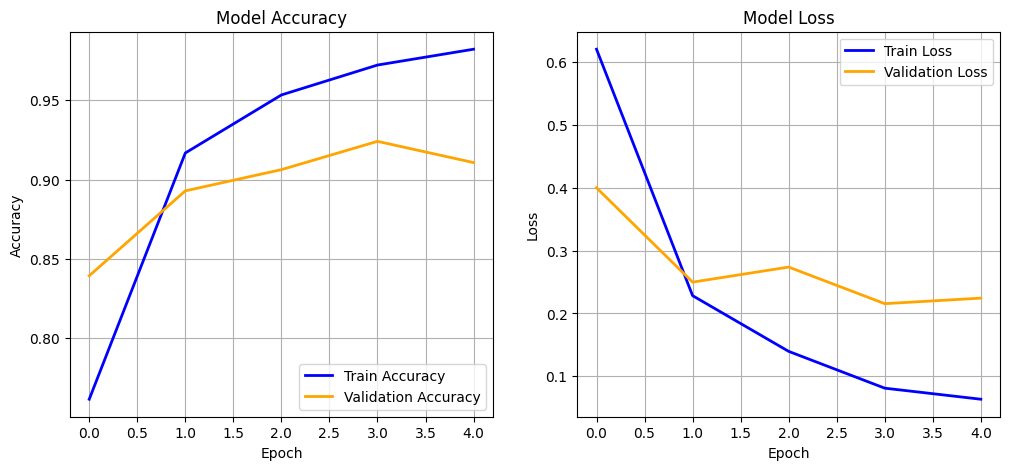

In [6]:
import matplotlib.pyplot as plt

# Set up the figure size
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


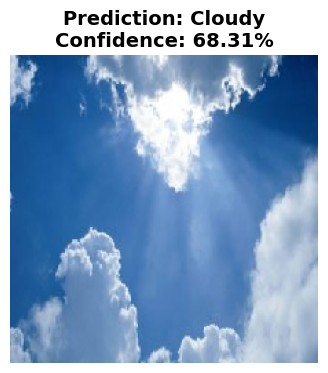

In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 👉 PASTE YOUR COPIED IMAGE PATH HERE:
TEST_IMAGE_PATH = "/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Shine/shine119.jpg"

# 1. Load and resize the image exactly like our training data (224x224)
img = image.load_img(TEST_IMAGE_PATH, target_size=(224, 224))

# 2. Convert to array and scale pixels between 0 and 1
img_array = image.img_to_array(img)
img_array = img_array / 255.0  

# 3. Add a "batch" dimension (because the model expects a batch of images, even if it's just 1)
img_array = np.expand_dims(img_array, axis=0)

# 4. Make the Prediction!
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)

# 5. Map the index back to the exact class names we found earlier
class_names = {0: 'Cloudy', 1: 'Rain', 2: 'Shine', 3: 'Sunrise'}
predicted_label = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

# 6. Show the image and the result
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [9]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Recreate the validation generator WITHOUT shuffling 
# This ensures our predictions align perfectly with the true labels
validation_generator_eval = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # <--- THIS IS CRITICAL
)

# 2. Get the true labels
y_true = validation_generator_eval.classes

# 3. Get the predictions from the model
print("\nRunning predictions on the 224 validation images. This takes a few seconds...")
predictions = model.predict(validation_generator_eval)
y_pred = np.argmax(predictions, axis=1)

# 4. Get the exact class names (Cloudy, Rain, Shine, Sunrise)
class_names = list(validation_generator_eval.class_indices.keys())

# 5. Print the beautiful report!
print("\n" + "="*50)
print("             CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

Found 224 images belonging to 4 classes.

Running predictions on the 224 validation images. This takes a few seconds...
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 768ms/step

             CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Cloudy       0.87      0.87      0.87        60
        Rain       1.00      1.00      1.00        43
       Shine       0.79      0.88      0.83        50
     Sunrise       1.00      0.92      0.96        71

    accuracy                           0.91       224
   macro avg       0.91      0.92      0.91       224
weighted avg       0.92      0.91      0.91       224



In [10]:

# 2. Save the trained model
model.save("weather_model.h5")
print("\nSuccess! Model saved to Kaggle output as 'weather_model.h5'")


Success! Model saved to Kaggle output as 'weather_model.h5'
